In [1]:
#importing necessary libraries

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import joblib
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import catboost as cb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,recall_score,f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder



In [2]:
pd.set_option('display.max_columns', None)

## Step 1 — Data Loading & Exploration

In [57]:
features = pd.read_csv(r'C:\Users\HP\Documents\Internship\water_pump_prediction\data\features.csv')
labels = pd.read_csv(r'C:\Users\HP\Documents\Internship\water_pump_prediction\data\labels.csv')  

In [61]:
labels.head(10)


,id,status_group
0,69572,functional
1,8776,functional
2,34310,functional
3,67743,non functional
4,19728,functional
5,9944,functional
6,19816,non functional
7,54551,non functional
8,53934,non functional
9,46144,functional


In [55]:
merged_data = pd.merge(features, labels, on='id')
merged_data.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,basin,subvillage,region,region_code,district_code,lga,ward,population,public_meeting,recorded_by,scheme_management,scheme_name,permit,construction_year,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,Lake Nyasa,Mnyusi B,Iringa,11,5,Ludewa,Mundindi,109,True,GeoData Consultants Ltd,VWC,Roman,False,1999,gravity,gravity,gravity,vwc,user-group,pay annually,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,Lake Victoria,Nyamara,Mara,20,2,Serengeti,Natta,280,NaN,GeoData Consultants Ltd,Other,NaN,True,2010,gravity,gravity,gravity,wug,user-group,never pay,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,Pangani,Majengo,Manyara,21,4,Simanjiro,Ngorika,250,True,GeoData Consultants Ltd,VWC,Nyumba ya mungu pipe scheme,True,2009,gravity,gravity,gravity,vwc,user-group,pay per bucket,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,Ruvuma / Southern Coast,Mahakamani,Mtwara,90,63,Nanyumbu,Nanyumbu,58,True,GeoData Consultants Ltd,VWC,NaN,True,1986,submersible,submersible,submersible,vwc,user-group,never pay,never pay,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,Lake Victoria,Kyanyamisa,Kagera,18,1,Karagwe,Nyakasimbi,0,True,GeoData Consultants Ltd,NaN,NaN,True,0,gravity,gravity,gravity,other,other,never pay,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional


In [28]:
#shape of the data
print("Shape of the data:", merged_data.shape)

Shape of the data: (59400, 41)


In [43]:
#selecting relevant features for analysis
cleaned_data = merged_data[['amount_tsh','gps_height','longitude','latitude','population','construction_year','date_recorded','basin','region','lga','extraction_type','management','payment_type','water_quality','quantity','source_type', 'waterpoint_type','public_meeting','permit', 'status_group']]

In [44]:
cleaned_data.isna().sum()

amount_tsh              0
gps_height              0
longitude               0
latitude                0
population              0
construction_year       0
date_recorded           0
basin                   0
region                  0
lga                     0
extraction_type         0
management              0
payment_type            0
water_quality           0
quantity                0
source_type             0
waterpoint_type         0
public_meeting       3334
permit               3056
status_group            0
dtype: int64

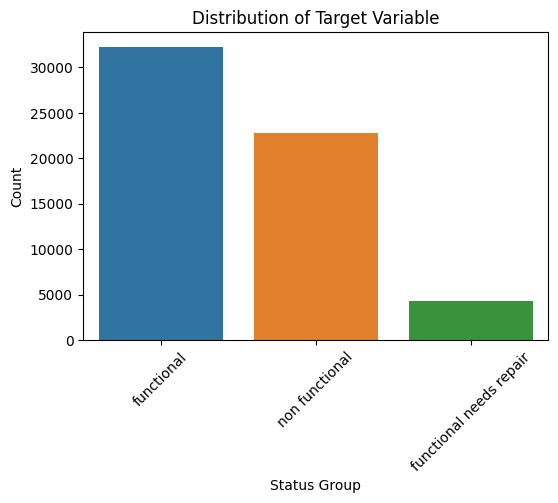

In [45]:
#plotting the percentage distribution of target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='status_group', data=cleaned_data, hue='status_group', legend=False)
plt.title('Distribution of Target Variable')
plt.xlabel('Status Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [46]:
#columns with suspicious zero values (e.g. coordinates, year, population)
suspicious_zero_columns = ['longitude', 'latitude', 'construction_year', 'population']
for column in suspicious_zero_columns:
    zero_count = (cleaned_data[column] == 0).sum()
    print(f"Number of zero values in '{column}': {zero_count}")


Number of zero values in 'longitude': 1812
Number of zero values in 'latitude': 0
Number of zero values in 'construction_year': 20709
Number of zero values in 'population': 21381


In [47]:
#number of unique values (cardinality) per categorical column
categorical_columns = cleaned_data.select_dtypes(include=['object']).columns
for column in categorical_columns:
    unique_values = cleaned_data[column].nunique()
    print(f"Number of unique values in '{column}': {unique_values}")


Number of unique values in 'date_recorded': 356
Number of unique values in 'basin': 9
Number of unique values in 'region': 21
Number of unique values in 'lga': 125
Number of unique values in 'extraction_type': 18
Number of unique values in 'management': 12
Number of unique values in 'payment_type': 7
Number of unique values in 'water_quality': 8
Number of unique values in 'quantity': 5
Number of unique values in 'source_type': 7
Number of unique values in 'waterpoint_type': 7
Number of unique values in 'public_meeting': 2
Number of unique values in 'permit': 2
Number of unique values in 'status_group': 3


## Step 2 — Data Cleaning & Feature Engineering


In [48]:
#convert date columns to datetime format
cleaned_data['date_recorded'] = pd.to_datetime(cleaned_data['date_recorded'], errors='coerce')

C:\Users\HP\AppData\Local\Temp\ipykernel_16364\3961222522.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_data['date_recorded'] = pd.to_datetime(cleaned_data['date_recorded'], errors='coerce')


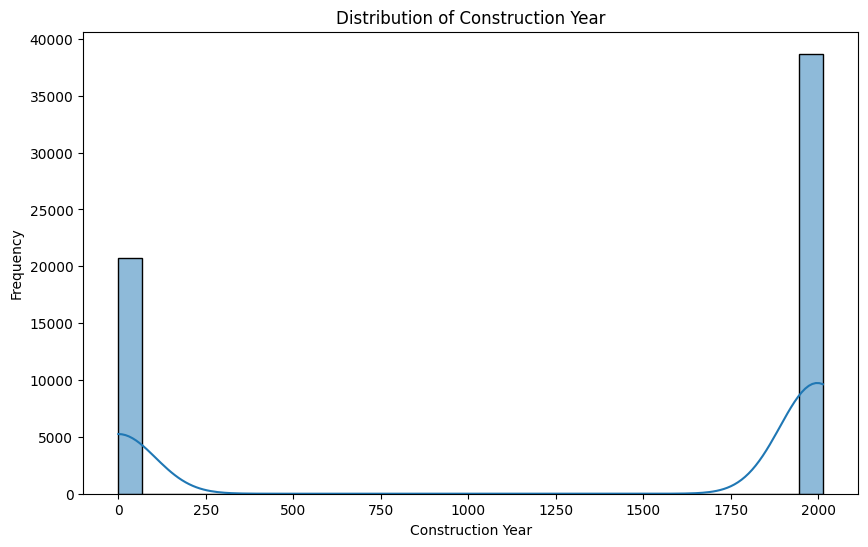

In [63]:
#construction year distribution
plt.figure(figsize=(10, 6))
sns.histplot(cleaned_data['construction_year'], bins=30, kde=True)
plt.title('Distribution of Construction Year')
plt.xlabel('Construction Year')
plt.ylabel('Frequency')
plt.show()

In [50]:
cleaned_data['construction_year'].describe()

count    59400.000000
mean      1300.652475
std        951.620547
min          0.000000
25%          0.000000
50%       1986.000000
75%       2004.000000
max       2013.000000
Name: construction_year, dtype: float64

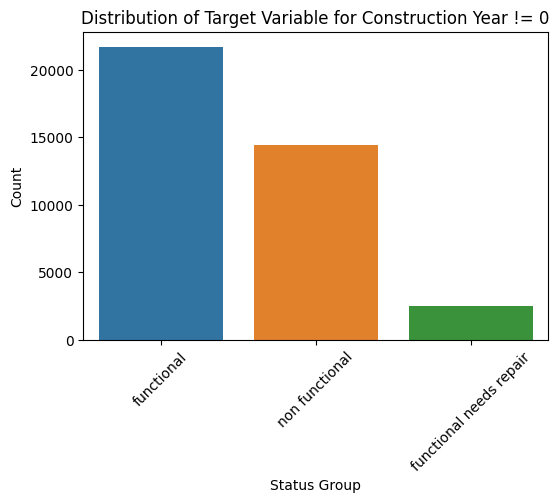

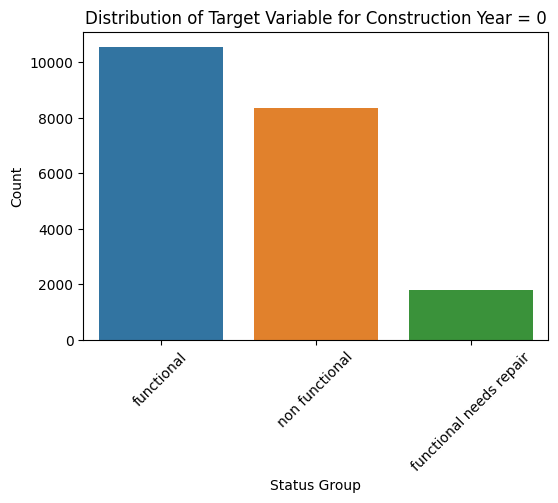

In [65]:
#construction_year with  values not equal to 0
non_zero_cd = cleaned_data[cleaned_data['construction_year'] != 0]
#distribution of target variable for construction_year with non-zero values
plt.figure(figsize=(6, 4))
sns.countplot(x='status_group', data=non_zero_cd, hue='status_group', legend=False)
plt.title('Distribution of Target Variable for Construction Year != 0')
plt.xlabel('Status Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


zero_cd=cleaned_data[cleaned_data['construction_year']==0]
#distribution of target variable for construction_year with 0 values
plt.figure(figsize=(6, 4))
sns.countplot(x='status_group', data=zero_cd, hue='status_group', legend=False)
plt.title('Distribution of Target Variable for Construction Year = 0')
plt.xlabel('Status Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [66]:
#create a new column for the year of recording
non_zero_cd['recorded_year']= non_zero_cd['date_recorded'].dt.year

C:\Users\HP\AppData\Local\Temp\ipykernel_16364\591526238.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_zero_cd['recorded_year']= non_zero_cd['date_recorded'].dt.year


In [70]:
non_zero_cd['construction_year'].describe()

count    38691.000000
mean      1996.814686
std         12.472045
min       1960.000000
25%       1987.000000
50%       2000.000000
75%       2008.000000
max       2013.000000
Name: construction_year, dtype: float64

In [71]:
#replacing construction_year values that are later than the recorded year with the median construction year
median_construction_year = non_zero_cd['construction_year'].median()
non_zero_cd.loc[non_zero_cd['construction_year'] > non_zero_cd['recorded_year'], 'construction_year'] = median_construction_year


In [73]:
#new column for pump age at the time of recording
non_zero_cd['pump_age']= non_zero_cd['recorded_year'] - non_zero_cd['construction_year']
non_zero_cd['pump_age'].describe()

C:\Users\HP\AppData\Local\Temp\ipykernel_16364\3332665649.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_zero_cd['pump_age']= non_zero_cd['recorded_year'] - non_zero_cd['construction_year']


count    38691.000000
mean        15.357603
std         12.490358
min          0.000000
25%          5.000000
50%         13.000000
75%         25.000000
max         53.000000
Name: pump_age, dtype: float64

In [74]:
#standardize values in 'extraction_type' column
non_zero_cd['extraction_type'] = non_zero_cd['extraction_type'].replace({
    'gravity': 'Gravity',
    'handpump': 'Hand Pump',
    'motorpump': 'Motor Pump',
    'submersible': 'Submersible',
    'swn 80': 'Swn 80',
    'nira/tanira': 'Nira/Tanira',
    'india mark ii': 'India Mark II',
    'ksb': 'KSB',
    'mono': 'Mono',
    'windmill': 'Windmill',
    'afridev': 'Afridev',
    'other - rope pump': 'Rope Pump',
    'india mark iii': 'India Mark III',
    'other - swn 81': 'Swn 81',
    'other - play pump': 'Play Pump',
    'cemo': 'Cemo',
    'climax': 'Climax',
    'walimi': 'Walimi',
    'other - mkulima/shinyanga': 'Mkulima/Shinyanga',
    'other': 'Other'
})

C:\Users\HP\AppData\Local\Temp\ipykernel_16364\2534570959.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_zero_cd['extraction_type'] = non_zero_cd['extraction_type'].replace({


In [75]:
#standardize values in 'management' column
non_zero_cd['management'] = non_zero_cd['management'].replace({
    'vwc': 'VWC',
    'wug': 'WUG',
    'other - school': 'School',
    'other - community': 'Community',
    'other - parastatal': 'Parastatal',
    'other - religious body': 'Religious Body',
    'other - water authority': 'Water Authority',
    'other - private operator': 'Private Operator',
    'other - company': 'Company',
    'other - ngo': 'NGO',
    'other - donor group': 'Donor Group',
    'other - local government': 'Local Government',
    'other - user-group management committee': 'User-Group Management Committee',
    'other - other': 'Other'
})

C:\Users\HP\AppData\Local\Temp\ipykernel_16364\2189774936.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_zero_cd['management'] = non_zero_cd['management'].replace({


In [76]:
non_zero_cd.columns

Index(['amount_tsh', 'gps_height', 'longitude', 'latitude', 'population',
       'construction_year', 'date_recorded', 'basin', 'region', 'lga',
       'extraction_type', 'management', 'payment_type', 'water_quality',
       'quantity', 'source_type', 'waterpoint_type', 'public_meeting',
       'permit', 'status_group', 'recorded_year', 'pump_age'],
      dtype='object')

In [77]:
y = non_zero_cd['status_group']
X = non_zero_cd.drop('status_group', axis=1)

In [78]:
X.shape, y.shape

((38691, 21), (38691,))

In [81]:
#function to create pump age feature
def create_pump_age(df):

    # COPY DATA
    df = df.copy()

    # CONVERT DATE
    df["date_recorded"] = pd.to_datetime(
        df["date_recorded"]
    )

    # EXTRACT YEAR
    df["recorded_year"] = (
        df["date_recorded"].dt.year
    )

    # HANDLE INVALID YEARS
    df["construction_year"] = np.where(

        df["construction_year"] == 0,

        np.nan,

        df["construction_year"]
    )

    # CREATE AGE
    df["pump_age"] = (

        df["recorded_year"]
        - df["construction_year"]
    )

    # REMOVE NEGATIVE VALUES
    df["pump_age"] = (
        df["pump_age"]
        .clip(lower=0)
    )

    # FILL MISSING VALUES
    df["pump_age"] = (
        df["pump_age"]
        .fillna(df["pump_age"].median())
    )

    return df

In [82]:
from sklearn.preprocessing import FunctionTransformer

pump_age_transformer = FunctionTransformer(create_pump_age)

In [83]:
#numerical features
numerical_features = ['amount_tsh', 'gps_height', 'longitude', 'latitude', 'population', 'construction_year', 'pump_age']
#categorical features
categorical_features = ['basin', 'region', 'lga', 'extraction_type', 'management', 'payment_type', 'water_quality', 'quantity', 'source_type', 'waterpoint_type', 'public_meeting', 'permit']


In [84]:
#column transformer for preprocessing
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [89]:
#models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=10)
}



In [90]:
pipeline= Pipeline(steps=[
    ('pump_age', pump_age_transformer),
    ('preprocessor', preprocessor),
    ('model', models['Logistic Regression'])
])

#splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

#fit the model
pipeline.fit(X_train, y_train)

#predict on the test set
y_pred = pipeline.predict(X_test)

#evaluate the model
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"Accuracy: {accuracy:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")



Accuracy: 0.7624
Recall: 0.7624
F1 Score: 0.7448


In [91]:
#saving the pipeline
joblib.dump(pipeline, 'water_pump_pipeline.joblib')


['water_pump_pipeline.joblib']